In [2]:
# ============================================================
# SPAM TESPİT MODELİ — TF-IDF + Naive Bayes / LR / SVM
# ============================================================

DATASET_PATH = '/kaggle/input/datasets/huseyinkaplan0/tez-spam-emails-tr'  # ← KENDİ YOLUN

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, re, time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

# Çıktı klasörü
os.makedirs('/kaggle/working/models', exist_ok=True)
os.makedirs('/kaggle/working/figures', exist_ok=True)

# Veri yükle
train = pd.read_csv(f'{DATASET_PATH}/spam_train.csv')
val = pd.read_csv(f'{DATASET_PATH}/spam_val.csv')
test = pd.read_csv(f'{DATASET_PATH}/spam_test.csv')

print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")
print(f"Train etiket: {train['label'].value_counts().to_dict()}")
print(f"Test etiket: {test['label'].value_counts().to_dict()}")

Train: 5381 | Val: 673 | Test: 673
Train etiket: {'spam': 2817, 'ham': 2564}
Test etiket: {'spam': 352, 'ham': 321}


In [3]:
# Türkçe metin temizleme
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http[s]?://\S+', ' URL ', text)
    text = re.sub(r'\b\d+\b', ' NUM ', text)
    text = re.sub(r'[^\wçğıöşüÇĞİÖŞÜ\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train['clean'] = train['text'].apply(clean_text)
val['clean'] = val['text'].apply(clean_text)
test['clean'] = test['text'].apply(clean_text)

# Etiket sayısallaştırma
y_train = (train['label'] == 'spam').astype(int)
y_val = (val['label'] == 'spam').astype(int)
y_test = (test['label'] == 'spam').astype(int)

# TF-IDF vektörleştirici
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)
X_train = vectorizer.fit_transform(train['clean'])
X_val = vectorizer.transform(val['clean'])
X_test = vectorizer.transform(test['clean'])

print(f"TF-IDF özellik sayısı: {X_train.shape[1]}")
print(f"Train shape: {X_train.shape}")

TF-IDF özellik sayısı: 10000
Train shape: (5381, 10000)


In [4]:
results = {}
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Linear SVM': CalibratedClassifierCV(LinearSVC(C=1.0, random_state=42, max_iter=2000), cv=3)
}

for name, model in models.items():
    print(f"\n{'='*50}\nEğitiliyor: {name}\n{'='*50}")
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    
    # Test
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        'accuracy': acc, 'precision': prec, 'recall': rec, 
        'f1': f1, 'roc_auc': auc, 'time_sec': elapsed,
        'y_pred': y_pred, 'y_proba': y_proba, 'model': model
    }
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"ROC-AUC: {auc:.4f}")
    print(f"Eğitim süresi: {elapsed:.2f}s")


Eğitiliyor: Naive Bayes
Accuracy: 0.9569
Precision: 0.9736
Recall: 0.9432
F1: 0.9582
ROC-AUC: 0.9867
Eğitim süresi: 0.01s

Eğitiliyor: Logistic Regression
Accuracy: 0.9688
Precision: 0.9742
Recall: 0.9659
F1: 0.9700
ROC-AUC: 0.9970
Eğitim süresi: 0.10s

Eğitiliyor: Linear SVM
Accuracy: 0.9881
Precision: 0.9886
Recall: 0.9886
F1: 0.9886
ROC-AUC: 0.9986
Eğitim süresi: 0.12s



=== MODEL KARŞILAŞTIRMA ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  Süre (sn)
Naive Bayes            0.9569     0.9736  0.9432    0.9582   0.9867     0.0103
Logistic Regression    0.9688     0.9742  0.9659    0.9700   0.9970     0.0976
Linear SVM             0.9881     0.9886  0.9886    0.9886   0.9986     0.1215


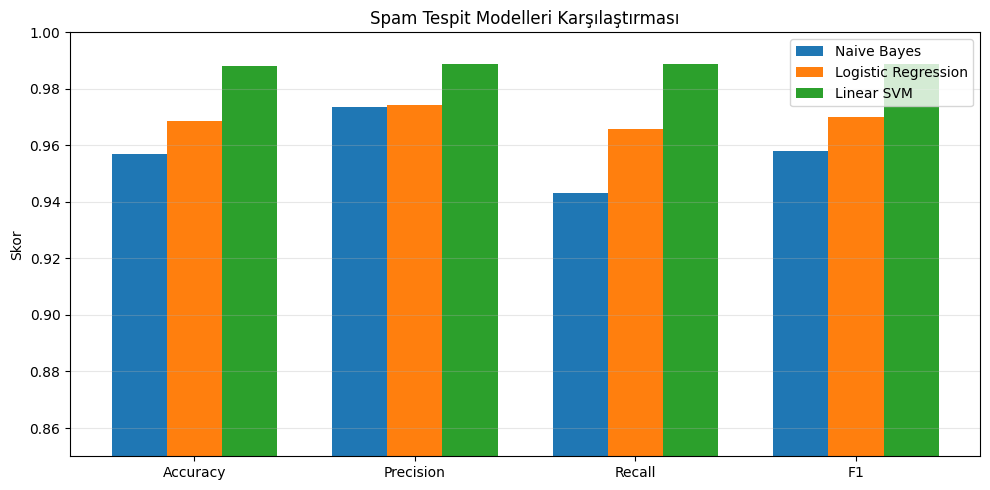

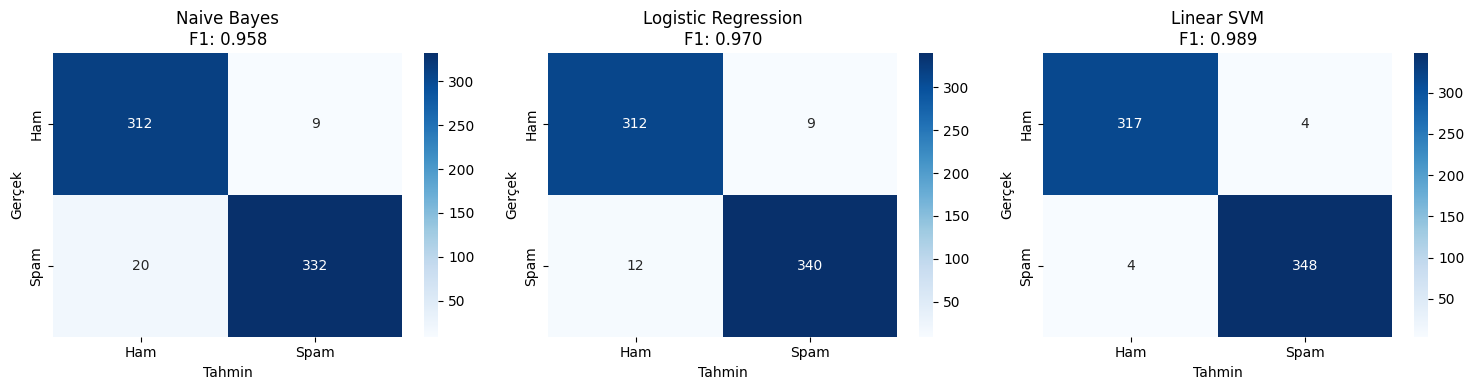

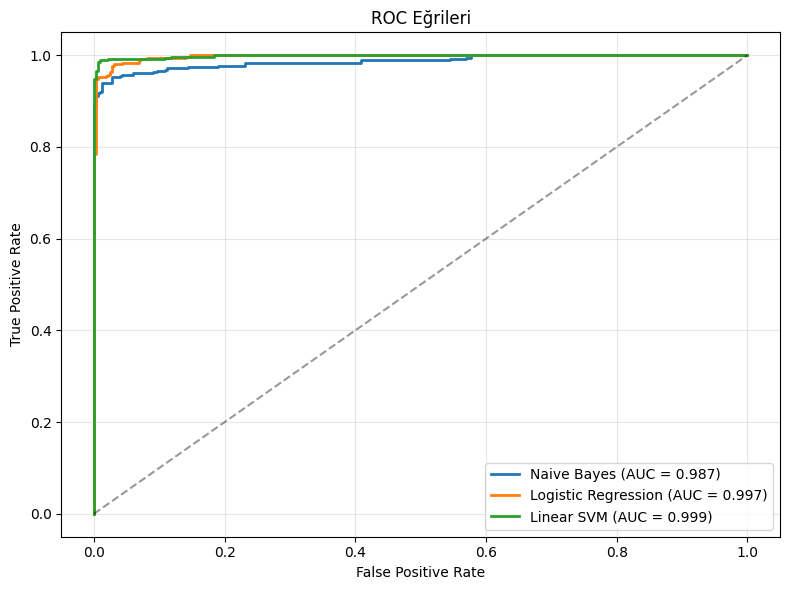

In [5]:
# Karşılaştırma tablosu
comparison = pd.DataFrame({
    name: {
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1-Score': r['f1'],
        'ROC-AUC': r['roc_auc'],
        'Süre (sn)': r['time_sec']
    } for name, r in results.items()
}).T

print("\n=== MODEL KARŞILAŞTIRMA ===")
print(comparison.round(4))
comparison.round(4).to_csv('/kaggle/working/model_comparison.csv')

# Bar chart — F1 karşılaştırma
fig, ax = plt.subplots(figsize=(10, 5))
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metrics_to_plot))
width = 0.25
for i, (name, r) in enumerate(results.items()):
    values = [r[m] for m in metrics_to_plot]
    ax.bar(x + i*width, values, width, label=name)
ax.set_xticks(x + width)
ax.set_xticklabels(['Accuracy','Precision','Recall','F1'])
ax.set_ylabel('Skor')
ax.set_title('Spam Tespit Modelleri Karşılaştırması')
ax.legend()
ax.set_ylim([0.85, 1.0])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrix — 3 model
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
    ax.set_title(f"{name}\nF1: {r['f1']:.3f}")
    ax.set_xlabel('Tahmin')
    ax.set_ylabel('Gerçek')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC eğrileri
fig, ax = plt.subplots(figsize=(8, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {r['roc_auc']:.3f})", linewidth=2)
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Eğrileri')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# En iyi modeli F1'e göre seç
best_name = max(results, key=lambda k: results[k]['f1'])
best_model = results[best_name]['model']
print(f"\n*** EN İYİ MODEL: {best_name} ***")
print(f"F1: {results[best_name]['f1']:.4f}")

# Kaydet
joblib.dump(best_model, '/kaggle/working/models/spam_classifier.pkl')
joblib.dump(vectorizer, '/kaggle/working/models/tfidf_vectorizer.pkl')
print("\n✓ Modeller kaydedildi: /kaggle/working/models/")


*** EN İYİ MODEL: Linear SVM ***
F1: 0.9886

✓ Modeller kaydedildi: /kaggle/working/models/



=== Linear SVM — Sınıflandırma Raporu ===
              precision    recall  f1-score   support

         Ham     0.9875    0.9875    0.9875       321
        Spam     0.9886    0.9886    0.9886       352

    accuracy                         0.9881       673
   macro avg     0.9881    0.9881    0.9881       673
weighted avg     0.9881    0.9881    0.9881       673



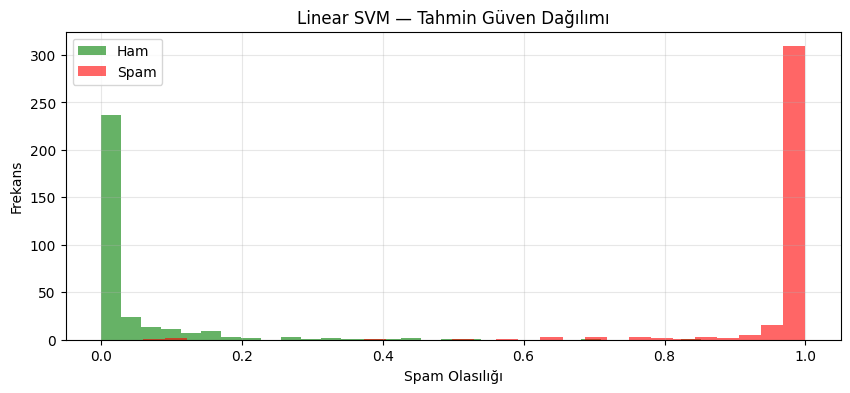

In [7]:
print(f"\n=== {best_name} — Sınıflandırma Raporu ===")
print(classification_report(y_test, results[best_name]['y_pred'], 
                            target_names=['Ham', 'Spam'], digits=4))

# Ayrıca güven dağılımı
plt.figure(figsize=(10, 4))
plt.hist(results[best_name]['y_proba'][y_test==0], bins=30, alpha=0.6, label='Ham', color='green')
plt.hist(results[best_name]['y_proba'][y_test==1], bins=30, alpha=0.6, label='Spam', color='red')
plt.xlabel('Spam Olasılığı')
plt.ylabel('Frekans')
plt.title(f'{best_name} — Tahmin Güven Dağılımı')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('/kaggle/working/figures/confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ============================================================
# Eğitilen modelin gerçek metinler üzerinde testi
# ============================================================

test_emails = [
    "BEDAVA!!! HEMEN TIKLA www.kazandiniz.com %100 KAZANDIN ŞIMDI AL ÖZEL FIRSAT ACIL!!!",
    "Sayın Hocam, Yarınki Kriptoloji dersi saat kaçta başlayacak? Bilgi rica ederim.",
    "ŞOK FİYAT! iPhone 15 sadece 999 TL!!! Stoklar tükenmek üzere TIKLA SATIN AL",
    "Merhaba, projemizin son teslim tarihini hatırlatmak istedim. Yarın 17:00'a kadar göndermeniz gerekiyor.",
    "TEBRIKLER 10000 TL KAZANDIN! Hesap bilgilerini hemen gonder paramı al http://sahte-banka.com",
    "Gelir İdaresi Başkanlığı, 2024 yılı vergi beyannamenizin son teslim tarihi 31 Mart'tır. Detaylar için resmi web sitemizi ziyaret ediniz."
]

print(f"\n{'='*70}")
print("LINEAR SVM — 6 GERÇEK METİN TESTİ")
print('='*70)

for i, email in enumerate(test_emails, 1):
    cleaned = clean_text(email)
    vec = vectorizer.transform([cleaned])
    pred = best_model.predict(vec)[0]
    proba = best_model.predict_proba(vec)[0][1]
    label = "SPAM" if pred == 1 else "HAM"
    print(f"\n[{i}] {label} (Spam olasılığı: %{proba*100:.1f})")
    print(f"    Metin: {email[:120]}{'...' if len(email)>120 else ''}")


LINEAR SVM — 6 GERÇEK METİN TESTİ

[1] SPAM (Spam olasılığı: %100.0)
    Metin: BEDAVA!!! HEMEN TIKLA www.kazandiniz.com %100 KAZANDIN ŞIMDI AL ÖZEL FIRSAT ACIL!!!

[2] HAM (Spam olasılığı: %0.2)
    Metin: Sayın Hocam, Yarınki Kriptoloji dersi saat kaçta başlayacak? Bilgi rica ederim.

[3] SPAM (Spam olasılığı: %98.6)
    Metin: ŞOK FİYAT! iPhone 15 sadece 999 TL!!! Stoklar tükenmek üzere TIKLA SATIN AL

[4] HAM (Spam olasılığı: %3.3)
    Metin: Merhaba, projemizin son teslim tarihini hatırlatmak istedim. Yarın 17:00'a kadar göndermeniz gerekiyor.

[5] SPAM (Spam olasılığı: %99.5)
    Metin: TEBRIKLER 10000 TL KAZANDIN! Hesap bilgilerini hemen gonder paramı al http://sahte-banka.com

[6] HAM (Spam olasılığı: %19.5)
    Metin: Gelir İdaresi Başkanlığı, 2024 yılı vergi beyannamenizin son teslim tarihi 31 Mart'tır. Detaylar için resmi web sitemizi...
